# Clustering Visualization, Interpretation and Final Synthesis — NYC PLUTO

This notebook completes the clustering phase by visualizing and interpreting the K-Means and DBSCAN results. It also answers the hierarchical clustering questions assigned to Ouri and provides the final synthesis of the clustering study.

The notebook does not redo preprocessing, K-Means tuning, or DBSCAN tuning. It loads the outputs produced by Elie and Alon whenever they are available.


## 1. Imports and Path Setup

All paths are resolved from the project root, so the notebook can run from the repository root or from `notebooks/04_clustering/`.


In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_samples, silhouette_score
from scipy.cluster.hierarchy import linkage, dendrogram

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120

RANDOM_STATE = 42
SAMPLE_SIZE = 10_000
SILHOUETTE_SAMPLE_SIZE = 10_000
KMEANS_SILHOUETTE_USED = 0.4680
DBSCAN_SILHOUETTE_USED = 0.4053
DBSCAN_EPS = 1.5
DBSCAN_MIN_SAMPLES = 40

search_dir = Path.cwd().resolve()
for candidate in [search_dir, *search_dir.parents]:
    if (candidate / "notebooks" / "02_preprocessing" / "preprocessing.ipynb").exists() and (candidate / "data" / "processed").exists():
        PROJECT_ROOT = candidate
        break
else:
    raise RuntimeError("Could not locate project root. Expected notebooks/02_preprocessing/preprocessing.ipynb and data/processed/.")

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

X_SCALED_PATH = PROCESSED_DIR / "X_scaled.csv"
FEATURES_PATH = PROCESSED_DIR / "X_scaled_features.csv"
SAMPLE_INDEX_PATH = PROCESSED_DIR / "sample_index.csv"
KMEANS_LABELS_PATH = PROCESSED_DIR / "cluster_labels.csv"
ALON_LABELS_PATH = PROCESSED_DIR / "dbscan_kmeans_sample_labels.csv"
COMPANION_PATH = PROCESSED_DIR / "pluto_companion.csv"

print(f"Project root: {PROJECT_ROOT}")
print(f"Processed data directory: {PROCESSED_DIR}")


Project root: /Users/ouriouahba/Desktop/NYC_PLUTO
Processed data directory: /Users/ouriouahba/Desktop/NYC_PLUTO/data/processed


## 2. Load Data and Existing Outputs

This section loads Elie's final standardized matrix and the available clustering labels. If Alon's DBSCAN labels are not available, only the final DBSCAN model is recomputed with `eps=1.5` and `min_samples=40` on the exact same working subset.


In [2]:
if not X_SCALED_PATH.exists():
    raise FileNotFoundError(f"Missing {X_SCALED_PATH}. Run Elie's preprocessing notebook first.")

X_scaled = pd.read_csv(X_SCALED_PATH)

if FEATURES_PATH.exists():
    feature_names = pd.read_csv(FEATURES_PATH)["feature"].tolist()
    if len(feature_names) == X_scaled.shape[1]:
        X_scaled.columns = feature_names
else:
    feature_names = list(X_scaled.columns)

rng = np.random.RandomState(RANDOM_STATE)
labels_source = []

# Prefer Alon's saved comparison labels if available; they already encode the exact 10,000-row subset.
if ALON_LABELS_PATH.exists():
    alon_labels = pd.read_csv(ALON_LABELS_PATH)
    required_cols = {"row_index", "dbscan_cluster", "kmeans_cluster"}
    if required_cols.issubset(alon_labels.columns):
        sample_idx = alon_labels["row_index"].astype(int).to_numpy()
        kmeans_labels = alon_labels["kmeans_cluster"].astype(int).to_numpy()
        dbscan_labels = alon_labels["dbscan_cluster"].astype(int).to_numpy()
        labels_source.append("Loaded DBSCAN and K-Means subset labels from Alon's dbscan_kmeans_sample_labels.csv")
    else:
        raise ValueError(f"{ALON_LABELS_PATH.name} exists but does not contain {required_cols}.")
else:
    # Recreate Alon's deterministic 10,000-row subset from the shared 50,000-row sample when possible.
    if SAMPLE_INDEX_PATH.exists():
        shared_sample_idx = pd.read_csv(SAMPLE_INDEX_PATH).iloc[:, 0].astype(int).to_numpy()
        selected_positions = rng.choice(len(shared_sample_idx), size=min(SAMPLE_SIZE, len(shared_sample_idx)), replace=False)
        sample_idx = shared_sample_idx[selected_positions]
        labels_source.append("Recreated the 10,000-row subset from sample_index.csv with random_state=42")
    else:
        sample_idx = rng.choice(X_scaled.index.to_numpy(), size=min(SAMPLE_SIZE, len(X_scaled)), replace=False)
        selected_positions = None
        labels_source.append("Recreated the 10,000-row subset directly from X_scaled with random_state=42")

    if KMEANS_LABELS_PATH.exists() and SAMPLE_INDEX_PATH.exists():
        saved_kmeans = pd.read_csv(KMEANS_LABELS_PATH, index_col=0)
        shared_sample_idx_for_labels = pd.read_csv(SAMPLE_INDEX_PATH).iloc[:, 0].astype(int).to_numpy()
        if "cluster" in saved_kmeans.columns and np.array_equal(saved_kmeans.index.astype(int).to_numpy(), shared_sample_idx_for_labels):
            kmeans_lookup = saved_kmeans["cluster"].astype(int)
            kmeans_labels = kmeans_lookup.loc[sample_idx].to_numpy()
            labels_source.append("Loaded K-Means labels from Elie's cluster_labels.csv")
        else:
            raise ValueError("K-Means labels exist but are not compatible with sample_index.csv.")
    else:
        raise FileNotFoundError("K-Means labels are required from Elie's output for Ouri's notebook.")

    X_for_dbscan = X_scaled.iloc[sample_idx].to_numpy(dtype=np.float32)
    dbscan_labels = DBSCAN(eps=DBSCAN_EPS, min_samples=DBSCAN_MIN_SAMPLES, n_jobs=-1).fit_predict(X_for_dbscan)
    labels_source.append("Recomputed final DBSCAN labels only, using eps=1.5 and min_samples=40")

if len(sample_idx) != SAMPLE_SIZE:
    print(f"Warning: working subset has {len(sample_idx):,} rows instead of {SAMPLE_SIZE:,}.")
if sample_idx.min() < 0 or sample_idx.max() >= len(X_scaled):
    raise ValueError("Working subset contains row positions outside X_scaled.")

X_sample = X_scaled.iloc[sample_idx].copy()
X_sample_array = X_sample.to_numpy(dtype=np.float32)

companion = pd.read_csv(COMPANION_PATH) if COMPANION_PATH.exists() else None
if companion is not None:
    companion_sample = companion.iloc[sample_idx].copy()
else:
    companion_sample = None

for item in labels_source:
    print("-", item)
print(f"Loaded X_scaled: {X_scaled.shape[0]:,} rows x {X_scaled.shape[1]} features")
print(f"Working subset: {len(sample_idx):,} rows")


- Loaded DBSCAN and K-Means subset labels from Alon's dbscan_kmeans_sample_labels.csv
Loaded X_scaled: 682,515 rows x 16 features
Working subset: 10,000 rows


## 3. Consistency Check

Both algorithms are compared on the same working subset, so the comparison is coherent.


In [3]:
consistency_df = pd.DataFrame({
    "item": [
        "X_scaled shape",
        "working subset size",
        "number of K-Means labels",
        "number of DBSCAN labels",
        "K-Means silhouette score used",
        "DBSCAN silhouette score used",
    ],
    "value": [
        str(X_scaled.shape),
        len(X_sample),
        len(kmeans_labels),
        len(dbscan_labels),
        f"{KMEANS_SILHOUETTE_USED:.4f}",
        f"{DBSCAN_SILHOUETTE_USED:.4f}",
    ],
})
consistency_df


,item,value
0,X_scaled shape,"(682515, 16)"
1,working subset size,10000
2,number of K-Means labels,10000
3,number of DBSCAN labels,10000
4,K-Means silhouette score used,0.4680
5,DBSCAN silhouette score used,0.4053


## 4. PCA Projection for Visualization

PCA is used only to project the high-dimensional data into two dimensions for visualization. It is not used as a clustering algorithm.


In [4]:
pca_2d = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca_2d.fit_transform(X_sample_array)

pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "KMeans label": kmeans_labels.astype(int),
    "DBSCAN label": dbscan_labels.astype(int),
})
pca_df["DBSCAN noise"] = pca_df["DBSCAN label"] == -1

explained_variance = pd.DataFrame({
    "component": ["PC1", "PC2"],
    "explained_variance_ratio": pca_2d.explained_variance_ratio_,
})
explained_variance


,component,explained_variance_ratio
0,PC1,0.239785
1,PC2,0.194704


## 5. K-Means Clusters Visualized with PCA

K-Means uses `k=2` and assigns every observation to one of the two clusters. Its silhouette score is `0.4680`, which suggests moderate separation rather than perfectly separated groups. The PCA plot is expected to show partial visual separation with some overlap because it compresses all clustering features into two dimensions.


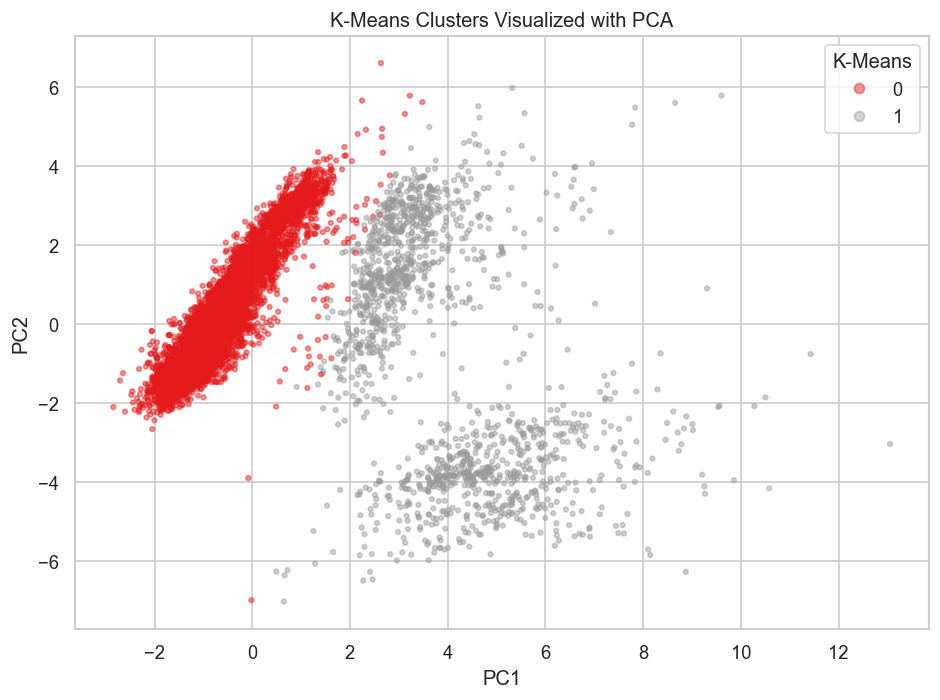

In [5]:
plt.figure(figsize=(8, 6))
scatter = plt.scatter(
    pca_df["PC1"],
    pca_df["PC2"],
    c=pca_df["KMeans label"],
    s=8,
    alpha=0.45,
    cmap="Set1",
)
plt.title("K-Means Clusters Visualized with PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(*scatter.legend_elements(), title="K-Means")
plt.tight_layout()
plt.show()


## 6. DBSCAN Clusters and Noise Visualized with PCA

DBSCAN uses `eps=1.5` and `min_samples=40`. It found 2 clusters, marks `16.22%` of points as noise, and has silhouette score `0.4053`. DBSCAN is useful because it does not force every point into a cluster and can identify atypical observations.


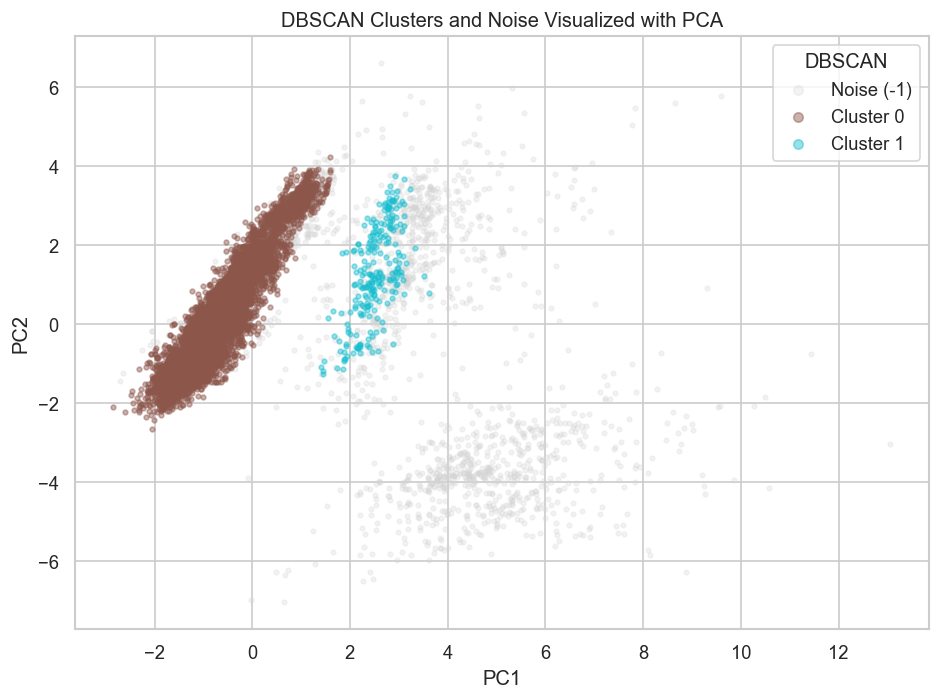

In [6]:
plt.figure(figsize=(8, 6))
unique_labels = sorted(pca_df["DBSCAN label"].unique())
colors = plt.cm.tab10(np.linspace(0, 1, max(len(unique_labels), 2)))

for color, label in zip(colors, unique_labels):
    mask = pca_df["DBSCAN label"] == label
    if label == -1:
        plt.scatter(pca_df.loc[mask, "PC1"], pca_df.loc[mask, "PC2"], s=8, alpha=0.25, c="lightgray", label="Noise (-1)")
    else:
        plt.scatter(pca_df.loc[mask, "PC1"], pca_df.loc[mask, "PC2"], s=8, alpha=0.45, color=color, label=f"Cluster {label}")

plt.title("DBSCAN Clusters and Noise Visualized with PCA")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title="DBSCAN", markerscale=2)
plt.tight_layout()
plt.show()


## 7. Individual Silhouette Plots

Silhouette values close to 1 indicate well-separated clusters. Values around 0 indicate overlap. Negative values may indicate poor assignment.

For DBSCAN, noise points (`-1`) are excluded from the silhouette plot because silhouette evaluates assigned clusters. This matches Alon's approach for DBSCAN silhouette reporting.


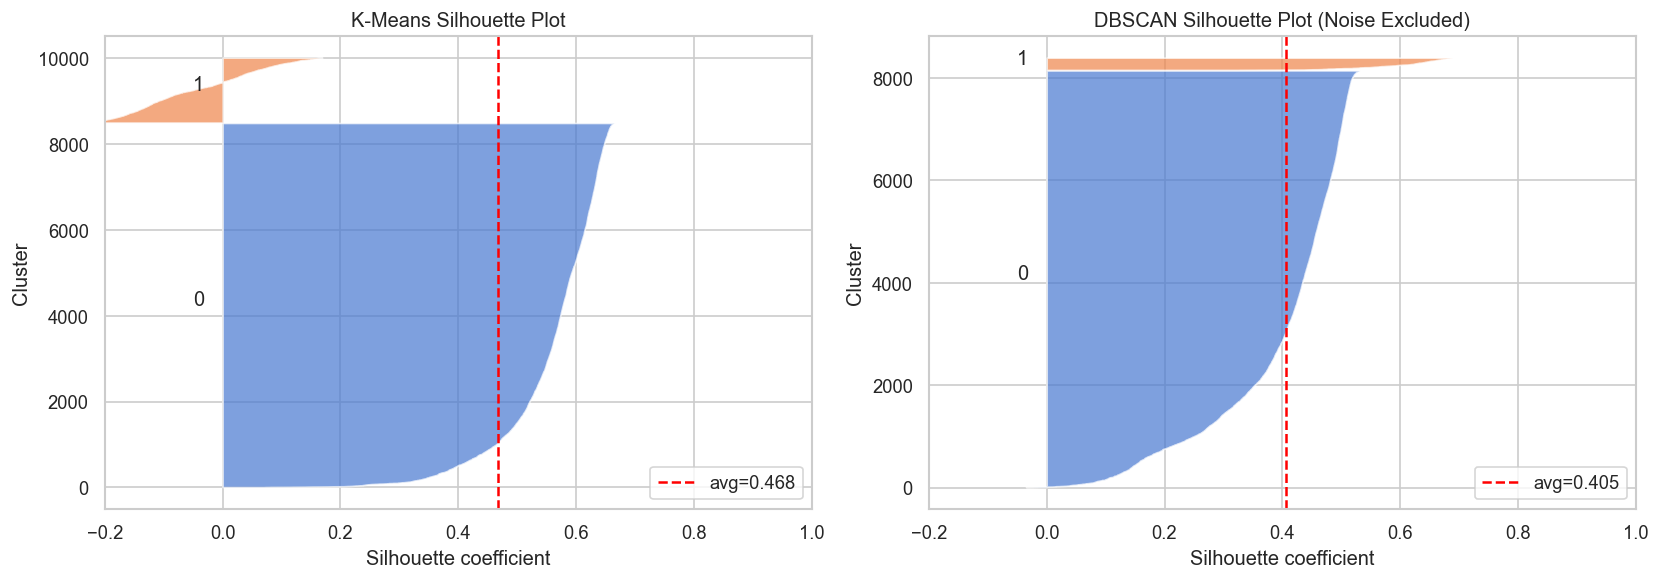

,algorithm,reported_silhouette,plot_silhouette
0,K-Means,0.4680,0.468043
1,DBSCAN,0.4053,0.405339


In [7]:
def plot_silhouette(ax, X, labels, title, exclude_noise=False):
    labels = np.asarray(labels)
    if exclude_noise:
        mask = labels != -1
        X_plot = X[mask]
        labels_plot = labels[mask]
    else:
        X_plot = X
        labels_plot = labels

    n_clusters = len(set(labels_plot))
    if len(labels_plot) < 3 or n_clusters < 2:
        ax.text(0.5, 0.5, "Silhouette is not valid", ha="center", va="center", transform=ax.transAxes)
        ax.set_title(title)
        return np.nan

    values = silhouette_samples(X_plot, labels_plot)
    avg_score = silhouette_score(X_plot, labels_plot, sample_size=min(SILHOUETTE_SAMPLE_SIZE, len(X_plot)), random_state=RANDOM_STATE)

    y_lower = 10
    for cluster_label in sorted(set(labels_plot)):
        cluster_values = np.sort(values[labels_plot == cluster_label])
        size = len(cluster_values)
        y_upper = y_lower + size
        ax.fill_betweenx(np.arange(y_lower, y_upper), 0, cluster_values, alpha=0.7)
        ax.text(-0.05, y_lower + size / 2, str(cluster_label))
        y_lower = y_upper + 10

    ax.axvline(avg_score, color="red", linestyle="--", linewidth=1.5, label=f"avg={avg_score:.3f}")
    ax.set_title(title)
    ax.set_xlabel("Silhouette coefficient")
    ax.set_ylabel("Cluster")
    ax.set_xlim([-0.2, 1.0])
    ax.legend(loc="lower right")
    return avg_score

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
kmeans_sil_plot = plot_silhouette(axes[0], X_sample_array, kmeans_labels, "K-Means Silhouette Plot")
dbscan_sil_plot = plot_silhouette(axes[1], X_sample_array, dbscan_labels, "DBSCAN Silhouette Plot (Noise Excluded)", exclude_noise=True)
plt.tight_layout()
plt.show()

pd.DataFrame({
    "algorithm": ["K-Means", "DBSCAN"],
    "reported_silhouette": [KMEANS_SILHOUETTE_USED, DBSCAN_SILHOUETTE_USED],
    "plot_silhouette": [kmeans_sil_plot, dbscan_sil_plot],
})


K-Means has silhouette score `0.4680`, while DBSCAN has silhouette score `0.4053`. According to silhouette score alone, K-Means is slightly stronger on the shared subset. DBSCAN remains useful because it separates dense groups while leaving atypical observations as noise.


## 8. K-Means Centroid Heatmap

If saved centroids are not available, centroids are computed from the scaled feature matrix by taking the mean of each scaled feature within each K-Means cluster. The heatmap shows the most differentiated features between the two centroids.


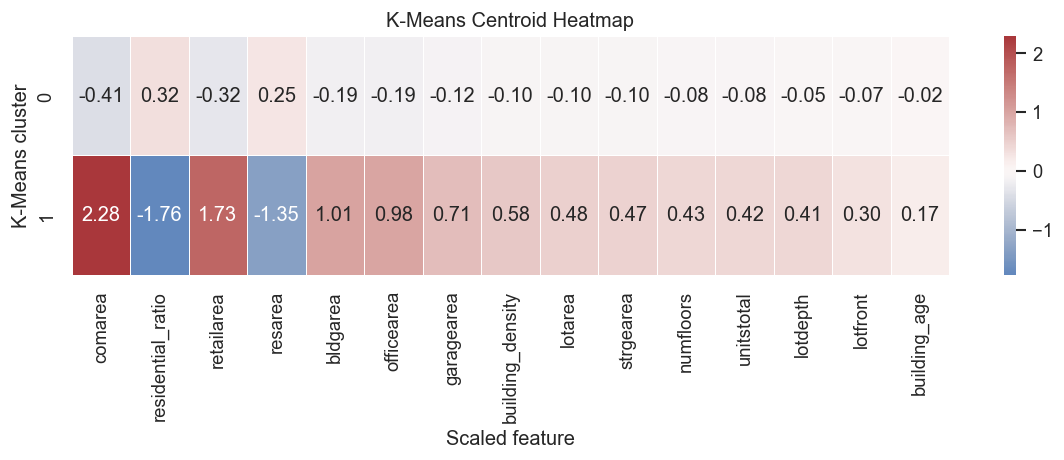

,comarea,residential_ratio,retailarea,resarea,bldgarea,officearea,garagearea,building_density,lotarea,strgearea,numfloors,unitstotal,lotdepth,lotfront,building_age
cluster,,,,,,,,,,,,,,,
0,-0.412,0.324,-0.318,0.254,-0.186,-0.194,-0.120,-0.099,-0.098,-0.100,-0.083,-0.079,-0.052,-0.070,-0.016
1,2.280,-1.761,1.730,-1.353,1.006,0.978,0.715,0.579,0.481,0.472,0.426,0.422,0.406,0.296,0.166


In [8]:
centroids_scaled = X_sample.assign(cluster=kmeans_labels).groupby("cluster").mean(numeric_only=True)
feature_range = (centroids_scaled.max(axis=0) - centroids_scaled.min(axis=0)).abs()
selected_features = feature_range.sort_values(ascending=False).head(min(15, len(feature_range))).index.tolist()

plt.figure(figsize=(10, 4))
sns.heatmap(
    centroids_scaled[selected_features],
    cmap="vlag",
    center=0,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
)
plt.title("K-Means Centroid Heatmap")
plt.xlabel("Scaled feature")
plt.ylabel("K-Means cluster")
plt.tight_layout()
plt.show()

centroids_scaled[selected_features].round(3)


The centroid heatmap should be read cautiously because values are standardized. Positive values indicate that a cluster is above the sample average for that feature, while negative values indicate below-average values. The most useful interpretation comes from comparing clusters feature by feature rather than treating the values as original units.


## 9. K-Means Cluster Profile Interpretation

This section uses original interpretable columns from `pluto_companion.csv` when available. These values are easier to interpret than standardized centroids.


In [9]:
if companion_sample is None:
    profile_summary = pd.DataFrame({"message": ["pluto_companion.csv was not available, so original feature profiles could not be computed."]})
else:
    profile_cols = [
        "lotarea", "bldgarea", "numfloors", "unitstotal", "unitsres",
        "resarea", "comarea", "building_age", "building_density", "residential_ratio",
    ]
    profile_cols = [c for c in profile_cols if c in companion_sample.columns]
    profile_data = companion_sample.copy()
    profile_data["KMeans cluster"] = kmeans_labels

    rows = []
    for cluster_label, group in profile_data.groupby("KMeans cluster"):
        row = {
            "cluster": int(cluster_label),
            "count": len(group),
            "percentage": round(len(group) / len(profile_data) * 100, 2),
        }
        for col in profile_cols:
            row[f"median_{col}"] = round(group[col].median(), 3)
        if "borough" in group.columns:
            row["main_borough"] = group["borough"].mode(dropna=True).iloc[0]
        if "landuse" in group.columns:
            row["main_landuse"] = group["landuse"].mode(dropna=True).iloc[0]
        rows.append(row)

    profile_summary = pd.DataFrame(rows).sort_values("cluster")

    if "median_bldgarea" in profile_summary.columns:
        high_intensity_cluster = profile_summary.sort_values("median_bldgarea").iloc[-1]["cluster"]
    else:
        high_intensity_cluster = profile_summary.sort_values("count").iloc[-1]["cluster"]

    profile_summary["profile_name"] = np.where(
        profile_summary["cluster"] == high_intensity_cluster,
        "Larger or higher-intensity buildings",
        "Typical lower-intensity buildings",
    )

profile_summary


,cluster,count,percentage,median_lotarea,median_bldgarea,median_numfloors,median_unitstotal,median_unitsres,median_resarea,median_comarea,median_building_age,median_building_density,median_residential_ratio,main_borough,main_landuse,profile_name
0,0,8487,84.87,2500.0,2050.0,2.0,2.0,2.0,1862.0,0.0,91.0,0.799,1.0,BK,1.0,Typical lower-intensity buildings
1,1,1513,15.13,3258.0,5164.0,3.0,3.0,1.0,1155.0,2500.0,95.0,1.010,0.5,BK,4.0,Larger or higher-intensity buildings


The two K-Means profiles are intentionally named cautiously. If the original feature medians show that one cluster has larger building area, more units, or higher density, it can reasonably be described as a larger or higher-intensity building group. The other cluster is better interpreted as the more typical lower-intensity group. These profiles make sense for NYC buildings because the city contains both many ordinary small residential lots and a smaller set of larger or more intensive properties.


## 10. DBSCAN Noise Interpretation

Noise points are not necessarily errors. They are observations that DBSCAN does not place in dense regions. They may represent atypical buildings or unusual combinations of features.


In [10]:
if companion_sample is None:
    dbscan_noise_summary = pd.DataFrame({"message": ["pluto_companion.csv was not available, so original feature noise profiles could not be computed."]})
else:
    noise_data = companion_sample.copy()
    noise_data["DBSCAN group"] = np.where(dbscan_labels == -1, "noise", "non-noise")
    rows = []
    for group_label, group in noise_data.groupby("DBSCAN group"):
        row = {
            "group": group_label,
            "count": len(group),
            "percentage": round(len(group) / len(noise_data) * 100, 2),
        }
        for col in profile_cols:
            row[f"median_{col}"] = round(group[col].median(), 3)
        rows.append(row)
    dbscan_noise_summary = pd.DataFrame(rows)

dbscan_noise_summary


,group,count,percentage,median_lotarea,median_bldgarea,median_numfloors,median_unitstotal,median_unitsres,median_resarea,median_comarea,median_building_age,median_building_density,median_residential_ratio
0,noise,1622,16.22,4007.0,5592.5,3.0,3.0,1.0,1360.0,2150.5,95.0,0.980,0.667
1,non-noise,8378,83.78,2458.0,2048.0,2.0,2.0,2.0,1840.0,0.0,91.0,0.799,1.000


The noise summary compares observations assigned to DBSCAN clusters with observations left as noise. Differences in medians can suggest what kinds of buildings DBSCAN considers atypical, but this should not be interpreted as proof of data errors.


## 11. K-Means vs DBSCAN Comparison Table

This table harmonizes the terminology used across the project and summarizes the practical trade-off between the two clustering algorithms.


In [11]:
comparison_table = pd.DataFrame({
    "Algorithm": ["K-Means", "DBSCAN"],
    "Main parameters": ["k=2", "eps=1.5, min_samples=40"],
    "Number of clusters": [2, 2],
    "Noise percentage": ["0%", "16.22%"],
    "Silhouette score": [f"{KMEANS_SILHOUETTE_USED:.4f}", f"{DBSCAN_SILHOUETTE_USED:.4f}"],
    "Main interpretation": [
        "Better silhouette, stable and easier to interpret, assigns all points.",
        "Slightly weaker silhouette, but useful for detecting atypical/noise observations.",
    ],
})
comparison_table


,Algorithm,Main parameters,Number of clusters,Noise percentage,Silhouette score,Main interpretation
0,K-Means,k=2,2,0%,0.4680,"Better silhouette, stable and easier to interp..."
1,DBSCAN,"eps=1.5, min_samples=40",2,16.22%,0.4053,"Slightly weaker silhouette, but useful for det..."


## 12. Optional Hierarchical Dendrogram

This section uses only the professor's six-point example, so it runs quickly. It does not run hierarchical clustering on the 10,000-row PLUTO subset.


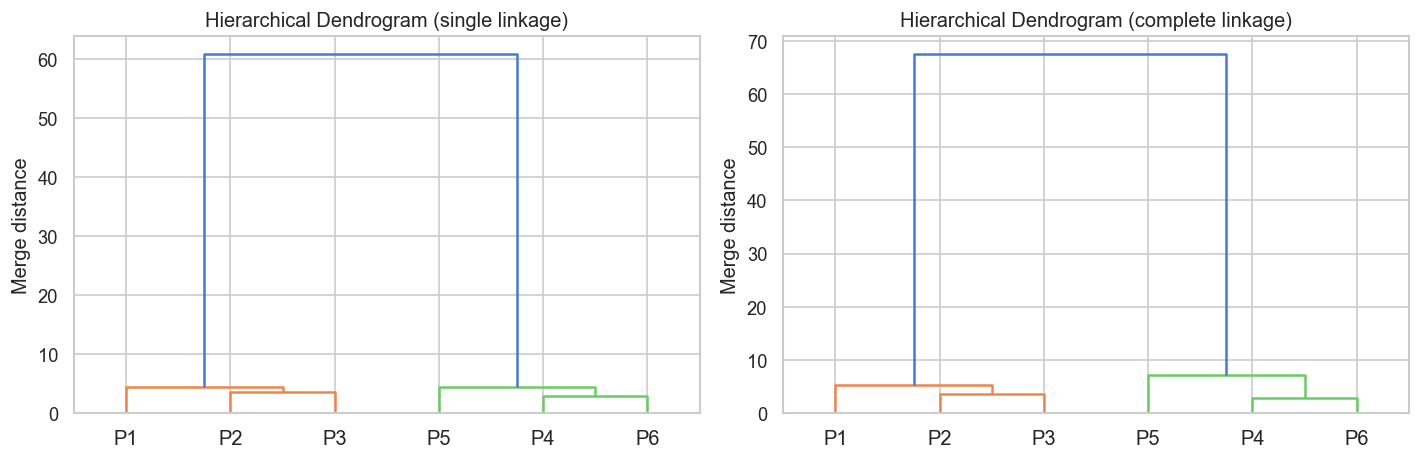

In [12]:
X_hier = np.array([
    [25, 30],
    [27, 35],
    [29, 32],
    [70, 80],
    [72, 76],
    [68, 82],
], dtype=float)
point_labels = ["P1", "P2", "P3", "P4", "P5", "P6"]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, method in zip(axes, ["single", "complete"]):
    Z = linkage(X_hier, method=method)
    dendrogram(Z, labels=point_labels, ax=ax)
    ax.set_title(f"Hierarchical Dendrogram ({method} linkage)")
    ax.set_ylabel("Merge distance")
plt.tight_layout()
plt.show()


## 13. Answers to Section 5 Questions — Hierarchical Clustering

### Q5.1. How does hierarchical clustering differ conceptually from K-Means?

K-Means requires choosing the number of clusters `k` in advance and directly partitions the data into `k` groups around centroids. Hierarchical clustering builds a tree of merges, called a dendrogram, starting from individual points and progressively merging clusters. It does not require choosing the final number of clusters at the beginning; we can choose it later by cutting the dendrogram.

### Q5.2. What is the difference between single linkage and complete linkage?

Single linkage defines the distance between two clusters as the minimum distance between any point in one cluster and any point in the other cluster. Complete linkage defines it as the maximum distance between points from the two clusters. Single linkage can create long chain-like clusters, while complete linkage tends to produce more compact clusters.

### Q5.3. In what sense can average linkage be viewed as a compromise between single and complete linkage?

Average linkage uses the average distance between all pairs of points across two clusters. It is a compromise because it does not depend only on the closest pair, like single linkage, and it does not depend only on the farthest pair, like complete linkage. It gives a more balanced measure of distance between clusters.

### Q5.4. What information does a dendrogram provide?

A dendrogram shows the order in which clusters are merged and the height at which each merge occurs. The height represents how dissimilar the merged clusters are. By cutting the dendrogram at a chosen height, we obtain a chosen number of clusters.

### Q5.5. In the professor's coding exercise, replacing `method='single'` with `method='complete'`: how does the dendrogram change?

With single linkage, clusters may merge based on only the closest pair of points, which can create chaining effects. With complete linkage, clusters merge only when all points are relatively close, so the dendrogram tends to show more compact and separated groups. In the small example, both methods still reveal two natural groups, but the merge heights and structure differ.

### Q5.6. In the professor's small example, does hierarchical clustering suggest a natural split into two clusters?

Yes. The first three points are close to one another and the last three points are close to one another, while the distance between these two groups is much larger. The dendrogram therefore suggests a natural split into two clusters.


## 14. Final Synthesis Conclusion

The project uses two clustering algorithms: K-Means and DBSCAN. This satisfies the mini-project requirement of comparing clustering algorithms.

K-Means gives the better silhouette score on the shared subset: `0.4680`. DBSCAN gives a slightly lower silhouette score: `0.4053`. DBSCAN is still useful because it identifies `16.22%` of observations as noise or atypical points.

For final interpretation, K-Means is the main model because it is more stable and easier to interpret. DBSCAN is a complementary model for detecting unusual buildings. The PCA plots are only visual aids.

The main limitations are:

1. clustering is unsupervised, so there are no true labels;
2. PCA is only a 2D projection and loses information;
3. results depend on preprocessing and parameter choices;
4. DBSCAN is sensitive to `eps` and `min_samples`;
5. the analysis is done on a subset of the full dataset.
